In [18]:
import os
from utils import *

import pennylane as qml
from pennylane import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 42

# Generating the dataset

We will generate a synthetic dataset, generated by solving the Lorentz system using the Euler method. The Lorenz equations are defined as:

$$
\dot{x} = \sigma (y-x)
$$
$$
\dot{y} = -y -zx + \rho x
$$
$$
\dot{z} = -\beta z +xy
$$

where $(x, y, z)$ are the variables and $(\sigma , \rho , \beta)$ are parameters. 

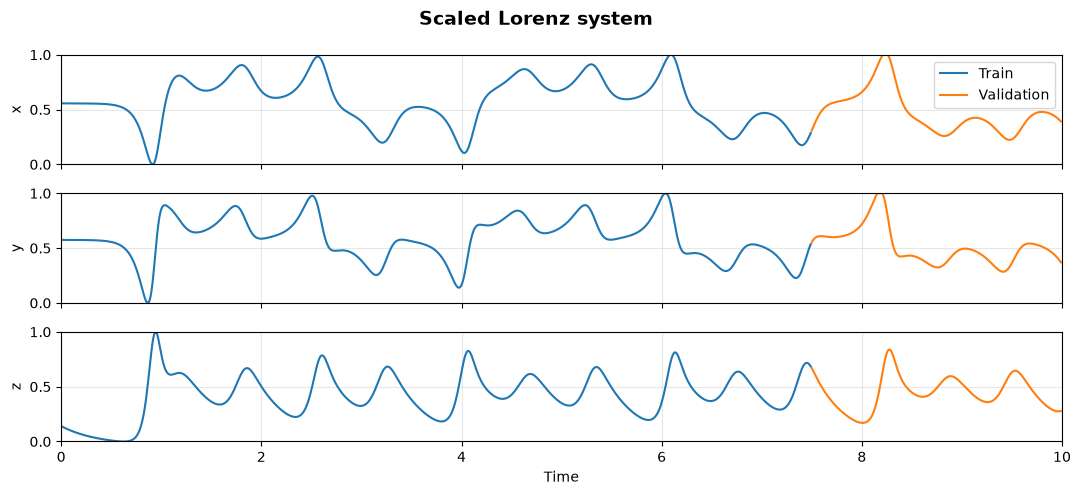

In [19]:
npoints = 1000
h = 0.01
params = [10, 28, 8 / 3]
init_point = [0, -0.01, 9]

dataset = generate_lorenz(
    npoints, 
    h,
    params, 
    init_point
)

# Trin test split
dataset_train, dataset_val = train_test_split(
    dataset,
    test_size=0.25,
    shuffle=False
)
time = np.arange(npoints) * h

time_tr = time[:len(dataset_train)]
time_val = time[len(dataset_train):]

# Scale the data to the range [0, 1]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(dataset_train)
val_scaled = scaler.transform(dataset_val)
val_scaled = np.clip(val_scaled, 0, 1)

plot_lorenz(train_scaled, val_scaled, time_tr, time_val)

# Data re-uploading

In this section, we use a data re-uploading architecture in which the number of qubits is equal to the number of input channels $C$. Each temporal step of the lookback window is sequentially encoded into the same quantum circuit, alternating feature-encoding layers with parameterized variational layers.

At each time step $t \in \{1, 2, \ldots, T\}$, the input is encoded through $R_y$ rotations and processed by a variational block:

$$
|\psi^{(t)}\rangle
=
U_{\mathrm{var}}(\theta^{(t)})
U_{\mathrm{enc}}(X_{:,t})
|\psi^{(t-1)}\rangle
$$

After the $T$ re-uploading steps, the final quantum state is measured using the Pauli-$Z$ operator on all qubits:

$$
\mathbf{Z}
=
[\langle Z_1\rangle, \ldots, \langle Z_C\rangle]
\in [-1,1]^C
$$

The measurement values are then rescaled to the interval $[0,1]$ to obtain the final prediction. Without additional classical post-processing, this architecture only supports single-step forecasting, $S=1$.

In [ ]:
# Params
batch_size = 128 
n_chanels = 3
window_size = 5
horizon = 1
nreps = 24
nqubits = n_chanels
params_per_step = 3  * nqubits * nreps
weights = {"theta": (params_per_step * window_size,)} #  We have "window_size" strongly entangling layers

# Training hyperparameters
epochs = 50
lr = 5e-4

In [27]:
# Create the sequences
x_tr, hor_tr = create_sequences(train_scaled, window_size, horizon)
x_val, hor_val = create_sequences(val_scaled, window_size, horizon)

x_tr = torch.from_numpy(x_tr).double()
hor_tr = torch.from_numpy(hor_tr).double()

x_val = torch.from_numpy(x_val).double()
hor_val = torch.from_numpy(hor_val).double()

tr_dataset = TensorDataset(x_tr, hor_tr)
tr_loader = DataLoader(tr_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# Create the PennyLane QNode
dev = qml.device("lightning.qubit", wires=nqubits)

def data_reupload(inputs, theta):
    inputs = inputs.reshape(-1, window_size, nqubits)
    for t in range(window_size):
        inputs_t = inputs[:, t, :]        
        start = t * params_per_step
        end = (t + 1) * params_per_step
        theta_t = theta[start:end]
        angle_encoding(nqubits, inputs_t)
        VQC_strong(nqubits, theta_t, nreps)

    output = [
        qml.expval(qml.Z(i))
        for i in range(nqubits)
    ]
    return output

data_reupload_node = qml.QNode(
    func=data_reupload,
    device=dev,
    interface="torch",
    diff_method="adjoint"
)

class Data_ReUpload_Model(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.reupload = qml.qnn.TorchLayer(data_reupload_node, weights)

    def forward(self, x):
        x = x.reshape(x.shape[0], window_size * nqubits)
        x = self.reupload(x) 
        return (x + 1) / 2 # (batch, 3)

In [44]:
reset_seeds(SEED)

# Create the model
model_Data_ReUpload = Data_ReUpload_Model().double()

print("Data Re-Upload Model:")
total, trainable = count_parameters(model_Data_ReUpload)
print(f"Total parameters: {total:,} | Trainable: {trainable:,}")

Data Re-Upload Model:
Total parameters: 1,080 | Trainable: 1,080


In [45]:
# Define optimizer and loss function
opt = torch.optim.Adam(params=model_Data_ReUpload.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Save the best model
best_state = None
best_val_loss = float("inf")

history = {"Loss": [], "Val loss": []}

print(30 * "#")
print("Starting training")
print(30 * "#")

for epoch in range(epochs):

    #Training
    model_Data_ReUpload.train()
    epoch_loss = 0
    for xb, yb in tr_loader:
        opt.zero_grad()
        pred = model_Data_ReUpload(xb)
        target = yb.reshape(yb.shape[0], -1)
        loss = loss_fn(pred, target)    
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    
    # Store average loss for this epoch
    epoch_loss /= len(tr_loader)
    history["Loss"].append(epoch_loss)

    # Evaluation
    model_Data_ReUpload.eval()
    with torch.no_grad():
        val_pred = model_Data_ReUpload(x_val)
        val_target = hor_val.reshape(hor_val.shape[0], -1)
        val_loss = loss_fn(val_pred, val_target).item()

    # Store val loss
    history["Val loss"].append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {
            name: params.detach().clone()
            for name, params in model_Data_ReUpload.state_dict().items()
        }

    # Print training progress every 5 epochs
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


if best_state is not None:
    model_Data_ReUpload.load_state_dict(best_state)

##############################
Starting training
##############################


Epoch: 1 | Loss: 0.0925 | Validation loss: 0.0482
Epoch: 5 | Loss: 0.0245 | Validation loss: 0.0153
Epoch: 10 | Loss: 0.0120 | Validation loss: 0.0079
Epoch: 15 | Loss: 0.0081 | Validation loss: 0.0049
Epoch: 20 | Loss: 0.0061 | Validation loss: 0.0032
Epoch: 25 | Loss: 0.0049 | Validation loss: 0.0024
Epoch: 30 | Loss: 0.0041 | Validation loss: 0.0020
Epoch: 35 | Loss: 0.0036 | Validation loss: 0.0018
Epoch: 40 | Loss: 0.0031 | Validation loss: 0.0016
Epoch: 45 | Loss: 0.0027 | Validation loss: 0.0015
Epoch: 50 | Loss: 0.0024 | Validation loss: 0.0014


In [46]:
# Save the model
os.makedirs("../models_states", exist_ok=True)

checkpoint = {
    "data_reupload": model_Data_ReUpload.state_dict(),
    "history": history
}
torch.save(checkpoint, "../models_states/data_reupload.pt")

In [47]:
# # Load the model
# checkpoint = torch.load(
#     "../models_states/data_reupload.pt",
#     map_location="cpu"
# )

# history = checkpoint["history"]

# model_Data_ReUpload = Data_ReUpload_Model().double()
# model_Data_ReUpload.load_state_dict(checkpoint["data_reupload"])

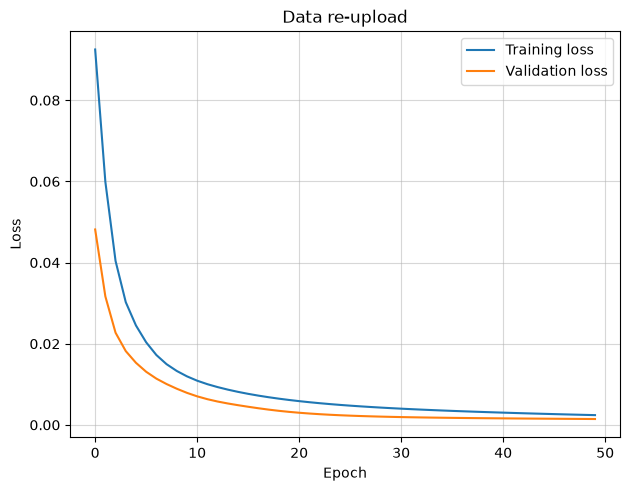

In [48]:
plot_loss(history, "Data re-upload")

In [49]:
# Evaluation mode
model_Data_ReUpload.eval()

with torch.no_grad():
    pred = model_Data_ReUpload(x_val)

pred_3d = pred.reshape(pred.shape[0], horizon, n_chanels)
target_3d = hor_val

# =====================
# RMSE
# =====================

squared_error = (pred_3d - target_3d) ** 2
mean_rmse_list = torch.sqrt(squared_error.mean(dim=(1, 2)))
mean_rmse = torch.sqrt(squared_error.mean())

# =====================
# MAE
# =====================

abs_error = torch.abs(pred_3d - target_3d)
mean_mae_list = abs_error.mean(dim=(1, 2))
mean_mae = abs_error.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error = torch.abs((target_3d - pred_3d) / (target_3d + eps))
mean_mape_list = percentage_error.mean(dim=(1, 2))
mean_mape = percentage_error.mean()

print(f"Global RMSE: {mean_rmse:.4f}")
print(f"Global MAE: {mean_mae:.4f}")
print(f"Global MAPE: {mean_mape:.4f}")

Global RMSE: 0.0381
Global MAE: 0.0289
Global MAPE: 0.0626


In [50]:
# Save the results to a CSV file
save_result_csv(
    "../results/lorenz_metrics.csv",
    {
        "forecasting": "short-term",
        "model": "Data re-upload",
        "MAPE": mean_mape,
        "MAE": mean_mae,
        "RMSE": mean_rmse,
    },
)

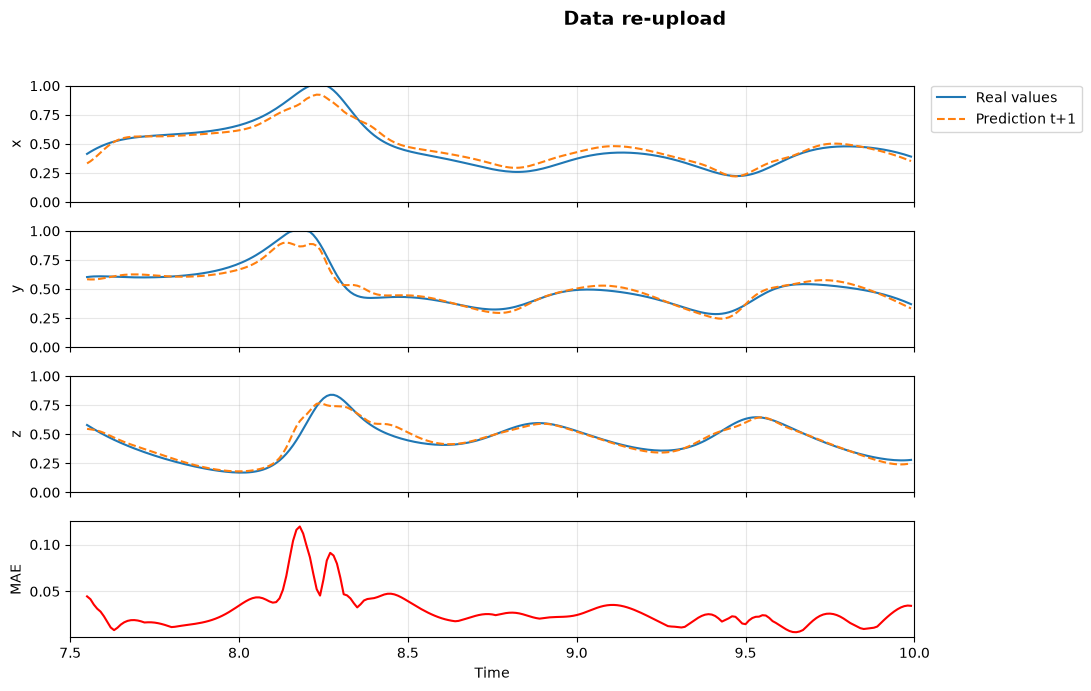

In [51]:
pred_x = pred_3d[:, :, 0]
pred_y = pred_3d[:, :, 1]
pred_z = pred_3d[:, :, 2]

plot_preds_and_error(
    pred_x,
    pred_y,
    pred_z,
    mean_mae_list,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    title="Data re-upload"
)